In [ ]:
# Cell 1: Initialization and Setup

# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown

# Print statement indicating this is the first cell
print("This is the first cell. Initialization and setup are done below:")

# Set IST timezone
ist = timezone('Asia/Kolkata')

# Date and time to display (Example: a specified past date and time)
specified_date = '2024-06-05'
specified_time = '13:09:34 IST+0530'

# Display the specified date in bold
display(Markdown(f'**Date: {specified_date}**'))

# Display the specified time in bold
display(Markdown(f'**Time: {specified_time}**'))


This is the first cell. Initialization and setup are done below:


**Date: 2024-06-05**

**Time: 13:09:34 IST+0530**

## Introduction
Greetings from the Kaggle bot! This is an automatically-generated kernel with starter code demonstrating how to read in the data and begin exploring. Click the blue "Edit Notebook" or "Fork Notebook" button at the top of this kernel to begin editing.

## Exploratory Analysis
To begin this exploratory analysis, first use `matplotlib` to import libraries and define functions for plotting the data. Depending on the data, not all plots will be made. (Hey, I'm just a kerneling bot, not a Kaggle Competitions Grandmaster!)

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [ ]:
# Install the gdown library
!pip install gdown

There is 1 csv file in the current version of the dataset:


In [ ]:
# Import necessary libraries
import gdown  # Importing gdown library for downloading files from Google Drive
import os     # Importing os library for operating system functionalities

# Define the URL of the Google Drive file
file_id = '1wLPa-XQclwBMptdm2ZG6VxG2Xl1QuKuV'  # ID of the file on Google Drive
url = f'https://drive.google.com/uc?id={file_id}'  # Constructing the download URL using file ID

# Download the file using gdown
output = 'uci-news-aggregator.csv'  # Output filename for the downloaded file
gdown.download(url, output, quiet=False)  # Downloading the file from Google Drive

# Check if the file is downloaded successfully
if os.path.exists(output):
    print(f"File '{output}' downloaded successfully!")  # Printing success message if file exists
else:
    print("File download failed.")  # Printing failure message if file does not exist


Downloading...
From: https://drive.google.com/uc?id=1wLPa-XQclwBMptdm2ZG6VxG2Xl1QuKuV
To: /content/uci-news-aggregator.csv
100%|██████████| 103M/103M [00:01<00:00, 58.2MB/s] 

File 'uci-news-aggregator.csv' downloaded successfully!


In [ ]:
# Cell 2: Check if the file is downloaded

import os

# Check if the file is downloaded
if os.path.exists(output):
    print("File downloaded successfully!")
else:
    print("File download failed.")


File downloaded successfully!


In [ ]:
# Cell 3: Display the first few rows of the dataframe

import pandas as pd

# Load the CSV file into a pandas dataframe
data = pd.read_csv(output)

# Display the first few rows of the dataframe
data.head()


,ID,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP
0,1,"Fed official says weak data caused by weather,...",http://www.latimes.com/business/money/la-fi-mo...,Los Angeles Times,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.latimes.com,1394470370698
1,2,Fed's Charles Plosser sees high bar for change...,http://www.livemint.com/Politics/H2EvwJSK2VE6O...,Livemint,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.livemint.com,1394470371207
2,3,US open: Stocks fall after Fed official hints ...,http://www.ifamagazine.com/news/us-open-stocks...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371550
3,4,"Fed risks falling 'behind the curve', Charles ...",http://www.ifamagazine.com/news/fed-risks-fall...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371793
4,5,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,http://www.moneynews.com/Economy/federal-reser...,Moneynews,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.moneynews.com,1394470372027


The next hidden code cells define functions for plotting data. Click on the "Code" button in the published kernel to reveal the hidden code.

In [ ]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = (nCol + nGraphPerRow - 1) / nGraphPerRow
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()


In [ ]:
# Correlation matrix
def plotCorrelationMatrix(df, graphWidth):
    filename = df.dataframeName
    df = df.dropna('columns') # drop columns with NaN
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of non-NaN or constant columns ({df.shape[1]}) is less than 2')
        return
    corr = df.corr()
    plt.figure(num=None, figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = plt.matshow(corr, fignum = 1)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15)
    plt.show()


In [ ]:
# Scatter and density plots
def plotScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include =[np.number]) # keep only numerical columns
    # Remove rows and columns that would lead to df being singular
    df = df.dropna('columns')
    df = df[[col for col in df if df[col].nunique() > 1]] # keep columns where there are more than 1 unique values
    columnNames = list(df)
    if len(columnNames) > 10: # reduce the number of columns for matrix inversion of kernel density plots
        columnNames = columnNames[:10]
    df = df[columnNames]
    ax = pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k = 1)):
        ax[i, j].annotate('Corr. coef = %.3f' % corrs[i, j], (0.8, 0.2), xycoords='axes fraction', ha='center', va='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()


Now you're ready to read in the data and use the plotting functions to visualize the data.

### Let's check 1st file: ../input/uci-news-aggregator.csv

In [ ]:
nRowsRead = 1000 # specify 'None' if want to read whole file

# uci-news-aggregator.csv has 422419 rows in reality, but we are only loading/previewing the first 1000 rows
df1 = pd.read_csv(output, delimiter=',', nrows = nRowsRead)
df1.dataframeName = 'uci-news-aggregator.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 1000 rows and 8 columns


Let's take a quick look at what the data looks like:

In [ ]:
df1.head(5)

,ID,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP
0,1,"Fed official says weak data caused by weather,...",http://www.latimes.com/business/money/la-fi-mo...,Los Angeles Times,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.latimes.com,1394470370698
1,2,Fed's Charles Plosser sees high bar for change...,http://www.livemint.com/Politics/H2EvwJSK2VE6O...,Livemint,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.livemint.com,1394470371207
2,3,US open: Stocks fall after Fed official hints ...,http://www.ifamagazine.com/news/us-open-stocks...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371550
3,4,"Fed risks falling 'behind the curve', Charles ...",http://www.ifamagazine.com/news/fed-risks-fall...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371793
4,5,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,http://www.moneynews.com/Economy/federal-reser...,Moneynews,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.moneynews.com,1394470372027


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

def plotPerColumnDistribution(df, nCols, nRows):
    """
    Plots the distribution of each column in the dataframe.

    Parameters:
    df (pandas.DataFrame): DataFrame containing the data to plot.
    nCols (int): Number of columns in the plot grid.
    nRows (int): Number of rows in the plot grid.
    """
    # Calculate the number of rows required, rounding up
    nCols = int(nCols)
    nRows = int(math.ceil(len(df.columns) / nCols))

    # Set up the matplotlib figure
    fig, axs = plt.subplots(nRows, nCols, figsize=(nCols*4, nRows*4))
    axs = np.array(axs)  # Ensure axs is a numpy array

    for i, column in enumerate(df.columns):
        if nRows == 1 or nCols == 1:
            ax = axs[i]
        else:
            ax = axs[i // nCols, i % nCols]
        sns.histplot(df[column], ax=ax, kde=True)
        ax.set_title(column)

    # Remove empty subplots
    if nRows > 1 and nCols > 1:
        for j in range(i+1, nRows * nCols):
            fig.delaxes(axs[j // nCols, j % nCols])

    plt.tight_layout()
    plt.show()


Distribution graphs (histogram/bar graph) of sampled columns:

<ipython-input-12-0b980324f882>:36: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


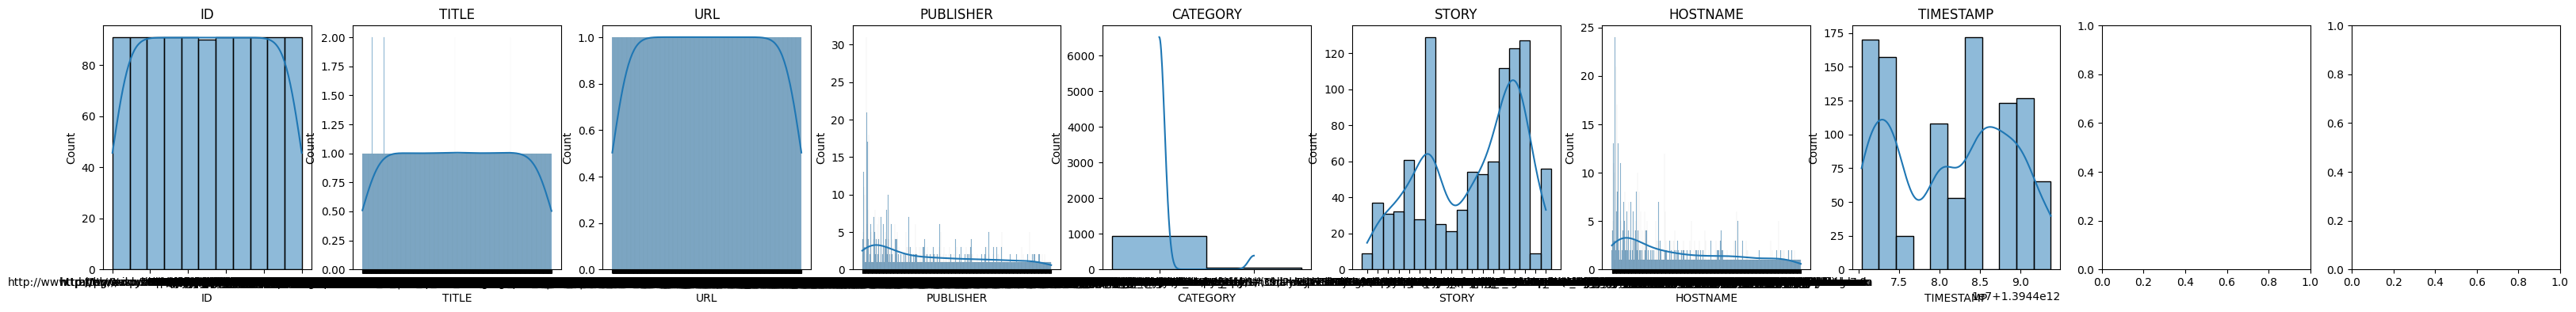

In [ ]:
plotPerColumnDistribution(df1, 10, 5)


## Conclusion
This concludes your starter analysis! To go forward from here, click the blue "Edit Notebook" button at the top of the kernel. This will create a copy of the code and environment for you to edit. Delete, modify, and add code as you please. Happy Kaggling!

In [ ]:
# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown

# Set IST timezone
ist = timezone('Asia/Kolkata')

# Get current time in IST
now_ist = datetime.now(ist)

# Format the date and time separately
formatted_date = now_ist.strftime('%Y-%m-%d')
formatted_time = now_ist.strftime('%H:%M:%S %Z%z')

# Print statement indicating this is the last cell and all above cells have been executed
print("All cells above have been executed. Below is the current date and time in IST:")

# Display the date in bold
display(Markdown(f'**Date: {formatted_date}**'))

# Display the time in bold
display(Markdown(f'**Time: {formatted_time}**'))


All cells above have been executed. Below is the current date and time in IST:


**Date: 2024-09-01**

**Time: 17:30:39 IST+0530**

### Q1: What is the purpose of the first code cell in the notebook?
A1: The first code cell is for initialization and setup. It imports necessary libraries for date/time handling and displays a specified date and time in bold.

### Q2: What library is used to download the dataset from Google Drive?
A2: The `gdown` library is used to download the dataset from Google Drive.

### Q3: What is the name of the downloaded dataset file?
A3: The downloaded dataset file is named `uci-news-aggregator.csv`.

### Q4: How many rows and columns are in the `df1` DataFrame after reading the first 1000 rows?
A4: There are 1000 rows and 8 columns in the `df1` DataFrame.

### Q5: What are the first few columns of the `df1` DataFrame?
A5: The first few columns are 'ID', 'TITLE', 'URL', 'PUBLISHER', 'CATEGORY', 'STORY', 'HOSTNAME', and 'TIMESTAMP'.

### Q6: What is the purpose of the `plotPerColumnDistribution` function?
A6: The `plotPerColumnDistribution` function is used to plot the distribution (histogram/bar graph) of columns in a DataFrame.

### Q7: What is the purpose of the last code cell in the notebook?
A7: The last code cell displays the current date and time in IST, indicating that all previous cells have been executed.

## Potential Interview Questions and Answers

### Q: Can you explain the steps involved in loading and previewing the data in this notebook?
A:
1.  First, the `gdown` library is installed to facilitate downloading files from Google Drive.
2.  The dataset file (`uci-news-aggregator.csv`) is downloaded from a specified Google Drive URL using `gdown.download()`.
3.  The downloaded CSV file is then loaded into a pandas DataFrame using `pd.read_csv()`. In this notebook, only the first 1000 rows are loaded for previewing.
4.  Finally, the `df.head()` method is used to display the first few rows of the DataFrame, providing a quick look at the data structure and content.

### Q: How would you handle a larger dataset that doesn't fit into memory?
A:
1.  **Process in chunks:** Read the data in smaller pieces using the `chunksize` parameter in `pd.read_csv()`.
2.  **Use data types efficiently:** Specify appropriate data types for columns to reduce memory usage (e.g., using `category` type for categorical data).
3.  **Select relevant columns:** Load only the columns necessary for the analysis.
4.  **Use libraries for big data:** Consider using libraries like Dask or Spark that are designed for handling larger-than-memory datasets.

### Q: What are some common data visualization techniques you might use after loading the data?
A:
1.  **Histograms/Bar plots:** To visualize the distribution of individual columns (as demonstrated in the notebook).
2.  **Scatter plots:** To explore the relationship between two numerical variables.
3.  **Box plots:** To visualize the distribution and identify outliers for numerical data, grouped by categories.
4.  **Correlation matrix/Heatmap:** To understand the correlation between numerical variables (as demonstrated in the notebook).
5.  **Count plots:** To visualize the frequency of categories in a categorical column.

### Q: How do you ensure your code is reproducible?
A:
1.  **Use version control:** Track changes to the code using Git.
2.  **Specify dependencies:** Use a `requirements.txt` or environment file (like `environment.yml` for Conda) to list all necessary libraries and their versions.
3.  **Set random seeds:** If using random processes, set a random seed for reproducibility.
4.  **Document your code:** Add comments and explanations to make the code understandable.
5.  **Use notebooks or scripts:** Organize code in a logical flow using notebooks or scripts.

## Summary and Potential Applications (ML Interview Prep)

Here are some potential interview questions and answers based on this notebook and the dataset:

*   **Q: What is the main purpose of this notebook?**
    *   **A:** This notebook serves as a starter kernel for exploring the "UCI News Aggregator Dataset". It demonstrates how to load the data, perform basic data inspection, and use predefined functions for initial data visualization (histograms and correlation matrices). It's a starting point for more in-depth exploratory data analysis.

*   **Q: Based on the dataset (news headlines and categories), what kind of machine learning tasks could be performed?**
    *   **A:** This dataset is well-suited for several NLP (Natural Language Processing) tasks, including:
        *   **News Categorization/Classification:** Predicting the category (e.g., business, technology, entertainment) of a news article based on its title and content.
        *   **Topic Modeling:** Identifying the main topics discussed in the news articles.
        *   **Sentiment Analysis:** Determining the sentiment (positive, negative, neutral) expressed in news headlines or articles.
        *   **News Article Summarization:** Generating concise summaries of news articles.
        *   **Named Entity Recognition (NER):** Identifying and classifying named entities (like persons, organizations, locations) in the text.

*   **Q: Can you provide sample use cases for a news categorization model built on this data?**
    *   **A:**
        *   **Content Recommendation:** Recommending news articles to users based on their interests and past reading history.
        *   **News Filtering and Organization:** Automatically sorting news into categories for easier browsing and consumption.
        *   **Trend Analysis:** Identifying emerging trends in different news categories.
        *   **Ad Targeting:** Displaying relevant advertisements based on the news category being viewed.

*   **Q: What are some real-world services or products that use concepts like news aggregation and categorization?**
    *   **A:**
        *   **Google News:** Aggregates news from various sources and categorizes them.
        *   **Apple News:** Similar to Google News, providing personalized news feeds based on categories.
        *   **News Apps (e.g., Flipboard, Reuters, Associated Press):** Use categorization to organize and deliver news content.
        *   **Social Media Platforms:** Employ algorithms to categorize and recommend news articles shared by users.
        *   **Financial News Platforms (e.g., Bloomberg, Refinitiv):** Categorize news to help users quickly find relevant information for market analysis.

*   **Q: What kind of insights can be gained from exploring this dataset?**
    *   **A:**
        *   **Distribution of news categories:** Understanding which categories are most prevalent in the dataset.
        *   **Most frequent publishers/hostnames:** Identifying the main sources of news.
        *   **Trends in news topics over time:** Analyzing how the focus of news changes.
        *   **Relationship between publishers and categories:** Seeing if certain publishers specialize in specific news areas.

*   **Q: What are the typical steps involved in building a news classification model using this data?**
    *   **A:**
        *   **Data Loading and Preprocessing:** Load the data, handle missing values, clean text data (e.g., remove punctuation, convert to lowercase, tokenization, remove stop words).
        *   **Feature Extraction:** Convert text data into numerical features using techniques like Bag-of-Words, TF-IDF, or word embeddings (Word2Vec, GloVe).
        *   **Model Selection:** Choose an appropriate classification algorithm (e.g., Naive Bayes, Support Vector Machines, Logistic Regression, or deep learning models like CNNs or RNNs).
        *   **Model Training:** Train the selected model on the prepared data.
        *   **Model Evaluation:** Evaluate the model's performance using metrics like accuracy, precision, recall, and F1-score.
        *   **Hyperparameter Tuning:** Optimize the model's hyperparameters for better performance.

*   **Q: What are some challenges you might face when working with this dataset for an ML task?**
    *   **A:**
        *   **Data Imbalance:** Some news categories might have significantly more articles than others, which can affect model training.
        *   **Noisy Text Data:** News headlines and articles can contain typos, grammatical errors, or inconsistent formatting.
        *   **Defining Categories:** The provided categories might be too broad or too specific for a particular task.
        *   **Handling New Words/Topics:** The model needs to be robust enough to handle new vocabulary and emerging topics.
        *   **Real-time Performance:** For applications like news recommendation, the model needs to be able to process and classify news quickly.